In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from typing import Literal

In [43]:
df = pd.read_csv("../data/train_raw.csv")

In [44]:
df.head()

,Patient_ID,Age,Gender,Occupation,BMI,Obesity_Class,Diet_Quality,Physical_Activity,Sleep_Hours,Smoking_Status,...,Comorb_Diabetes,Comorb_Hypertension,Comorb_Genetic_History,ALT,AST,Bilirubin,Albumin,Platelets,Alk_Phosphatase,Liver_Disease_Type
0,P23743,49,Male,Healthcare Worker,21.0,Normal,Average,Moderate,4.9,Never,...,0,0,0,25.58,29.30,1.26,4.74,334,119,Fatty_Liver
1,P59795,49,Male,Business,22.6,Normal,Healthy,Low,8.2,Current,...,0,1,0,22.98,30.41,0.73,3.67,224,89,Normal
2,P17597,66,Male,Healthcare Worker,19.5,Normal,Poor,Low,5.1,Never,...,0,0,0,65.46,45.63,0.70,4.27,304,109,Fatty_Liver
3,P27987,75,Female,Office Worker,21.5,Normal,Average,Moderate,6.2,Former,...,0,0,0,55.88,74.40,0.98,4.12,367,102,Alcoholic_Liver_Disease
4,P45429,51,Female,Housewife,22.8,Normal,Poor,Low,7.8,Never,...,1,1,0,72.63,49.17,2.79,4.12,49,114,Cirrhosis


In [45]:
df = df.drop(columns=["Patient_ID"])

Patient_ID - Идентификатор пациента  \
Age - Возраст \
Gender - Пол \
Occupation - Профессия \
BMI - ИМТ (Индекс массы тела) \
Obesity_Class - Класс ожирения \
Diet_Quality - Качество питания \
Physical_Activity - Физическая активность \
Sleep_Hours - Длительность сна (в часах) \
Smoking_Status - Статус курения \
Alcohol_Consumption - Употребление алкоголя \
Sym_Fatigue - Симптом: Утомляемость \
Sym_Jaundice - Симптом: Желтуха \
Sym_Abdominal_Pain - Симптом: Боль в животе \
Sym_Itching - Симптом: Зуд \
Sym_Ascites - Симптом: Асцит \
Sym_Dark_Urine - Симптом: Тёмная моча \
Sym_Weight_Loss - Симптом: Потеря веса \
Comorb_Diabetes - Сахарный диабет (сопутствующее заболевание) \
Comorb_Hypertension - Артериальная гипертензия (сопутствующее заболевание) \
Comorb_Genetic_History - Генетический анамнез (наследственная предрасположенность) \
ALT - АЛТ (Аланинаминотрансфераза) \
AST - АСТ (Аспартатаминотрансфераза) \
Bilirubin - Билирубин \
Albumin - Альбумин \
Platelets - Тромбоциты \
Alk_Phosphatase - Щелочная фосфатаза \
Liver_Disease_Type - Тип заболевания печени:
- Fatty_Liver - Жировая болезнь печени (стеатоз)
- Normal - Норма (здоровая печень)
- Alcoholic_Liver_Disease - Алкогольная болезнь печени
- Cirrhosis - Цирроз печени
- Hepatitis_B - Гепатит B
- Hepatitis_C - Гепатит C


In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 68000 entries, 0 to 67999
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     68000 non-null  int64  
 1   Gender                  68000 non-null  str    
 2   Occupation              68000 non-null  str    
 3   BMI                     68000 non-null  float64
 4   Obesity_Class           68000 non-null  str    
 5   Diet_Quality            68000 non-null  str    
 6   Physical_Activity       68000 non-null  str    
 7   Sleep_Hours             68000 non-null  float64
 8   Smoking_Status          68000 non-null  str    
 9   Alcohol_Consumption     37377 non-null  str    
 10  Sym_Fatigue             68000 non-null  int64  
 11  Sym_Jaundice            68000 non-null  int64  
 12  Sym_Abdominal_Pain      68000 non-null  int64  
 13  Sym_Itching             68000 non-null  int64  
 14  Sym_Ascites             68000 non-null  int64  
 

In [47]:
cat_cols = df.select_dtypes(exclude='number')

In [48]:
for col in cat_cols.columns:
    print(col)
    print(df[col].unique(), end='\n\n')

Gender
<StringArray>
['Male', 'Female']
Length: 2, dtype: str

Occupation
<StringArray>
['Healthcare Worker',          'Business',     'Office Worker',
         'Housewife',           'Student',            'Farmer',
           'Laborer',           'Retired']
Length: 8, dtype: str

Obesity_Class
<StringArray>
['Normal', 'Obesity I', 'Overweight', 'Underweight', 'Obesity II',
 'Obesity III']
Length: 6, dtype: str

Diet_Quality
<StringArray>
['Average', 'Healthy', 'Poor']
Length: 3, dtype: str

Physical_Activity
<StringArray>
['Moderate', 'Low', 'Sedentary', 'High']
Length: 4, dtype: str

Smoking_Status
<StringArray>
['Never', 'Current', 'Former']
Length: 3, dtype: str

Alcohol_Consumption
<StringArray>
['Low', 'Moderate', nan, 'High']
Length: 4, dtype: str

Liver_Disease_Type
<StringArray>
[            'Fatty_Liver',                  'Normal',
 'Alcoholic_Liver_Disease',               'Cirrhosis',
             'Hepatitis_B',             'Hepatitis_C']
Length: 6, dtype: str



In [49]:
df['Alcohol_Consumption'].unique()

<StringArray>
['Low', 'Moderate', nan, 'High']
Length: 4, dtype: str

In [50]:
# Есть вероятность, что люди с высоким потреблением алкоголя склонны не сообщать это
# Поэтому кроме заполнения пропусков еще добавлена дополнительная колонка индикатор

df['Alcohol_Missing'] = df['Alcohol_Consumption'].isna().astype(int)
df['Alcohol_Consumption'] = df['Alcohol_Consumption'].fillna("UNKNOWN")

In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 68000 entries, 0 to 67999
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     68000 non-null  int64  
 1   Gender                  68000 non-null  str    
 2   Occupation              68000 non-null  str    
 3   BMI                     68000 non-null  float64
 4   Obesity_Class           68000 non-null  str    
 5   Diet_Quality            68000 non-null  str    
 6   Physical_Activity       68000 non-null  str    
 7   Sleep_Hours             68000 non-null  float64
 8   Smoking_Status          68000 non-null  str    
 9   Alcohol_Consumption     68000 non-null  str    
 10  Sym_Fatigue             68000 non-null  int64  
 11  Sym_Jaundice            68000 non-null  int64  
 12  Sym_Abdominal_Pain      68000 non-null  int64  
 13  Sym_Itching             68000 non-null  int64  
 14  Sym_Ascites             68000 non-null  int64  
 

In [52]:
numeric_cols = df.select_dtypes(include='number')

In [53]:
binary_cols = [col for col in numeric_cols.columns if len(df[col].unique()) == 2]

In [54]:
non_binary_cols = [col for col in numeric_cols.columns if len(df[col].unique()) > 2]

In [55]:
def plot(data: pd.DataFrame, columns: list[str], cols_type: Literal["categorical", "numeric"] = "numeric"):
    n_cols = 3
    n_rows = int(np.ceil(len(columns) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(columns):
        if cols_type == "numeric":
            sns.histplot(data=data, x=col, ax=axes[i], bins=min(30, len(data[col].unique())))
        elif cols_type == "categorical":
            sns.countplot(data=data, x=col, ax=axes[i])
        else:
            raise TypeError("Unsupported columns type")
        
        axes[i].set_title(col, fontsize=11)
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

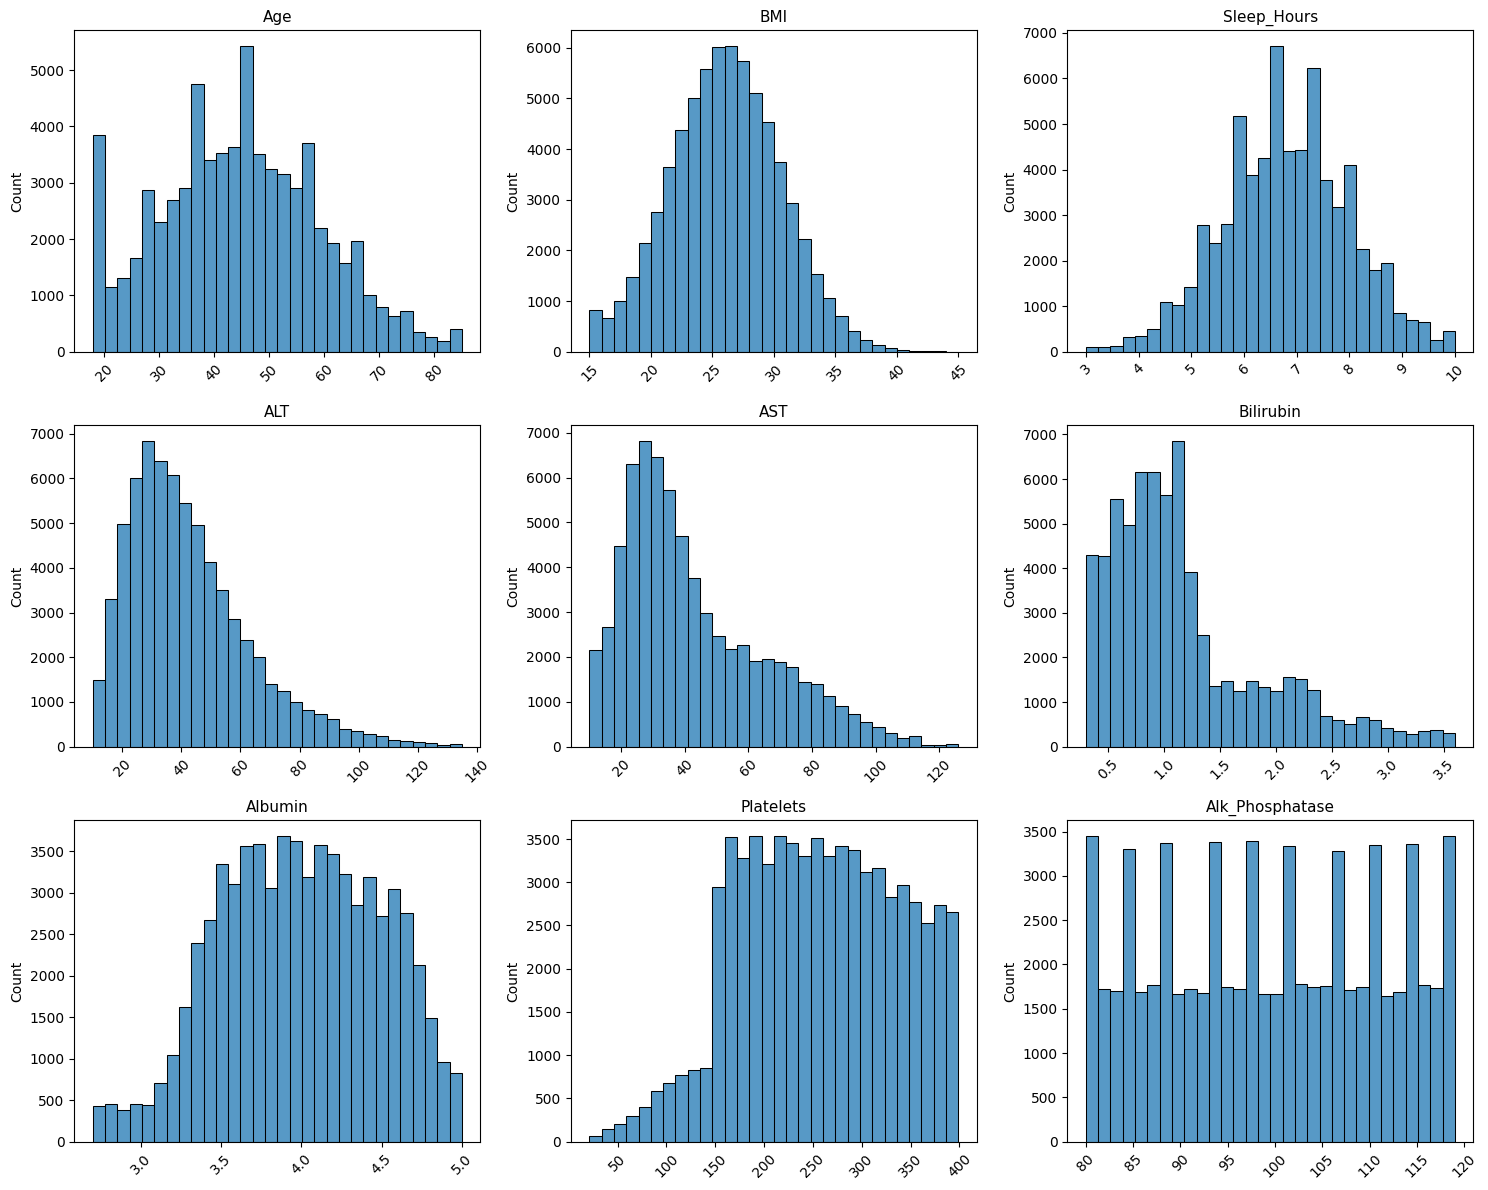

In [56]:
plot(df, non_binary_cols)

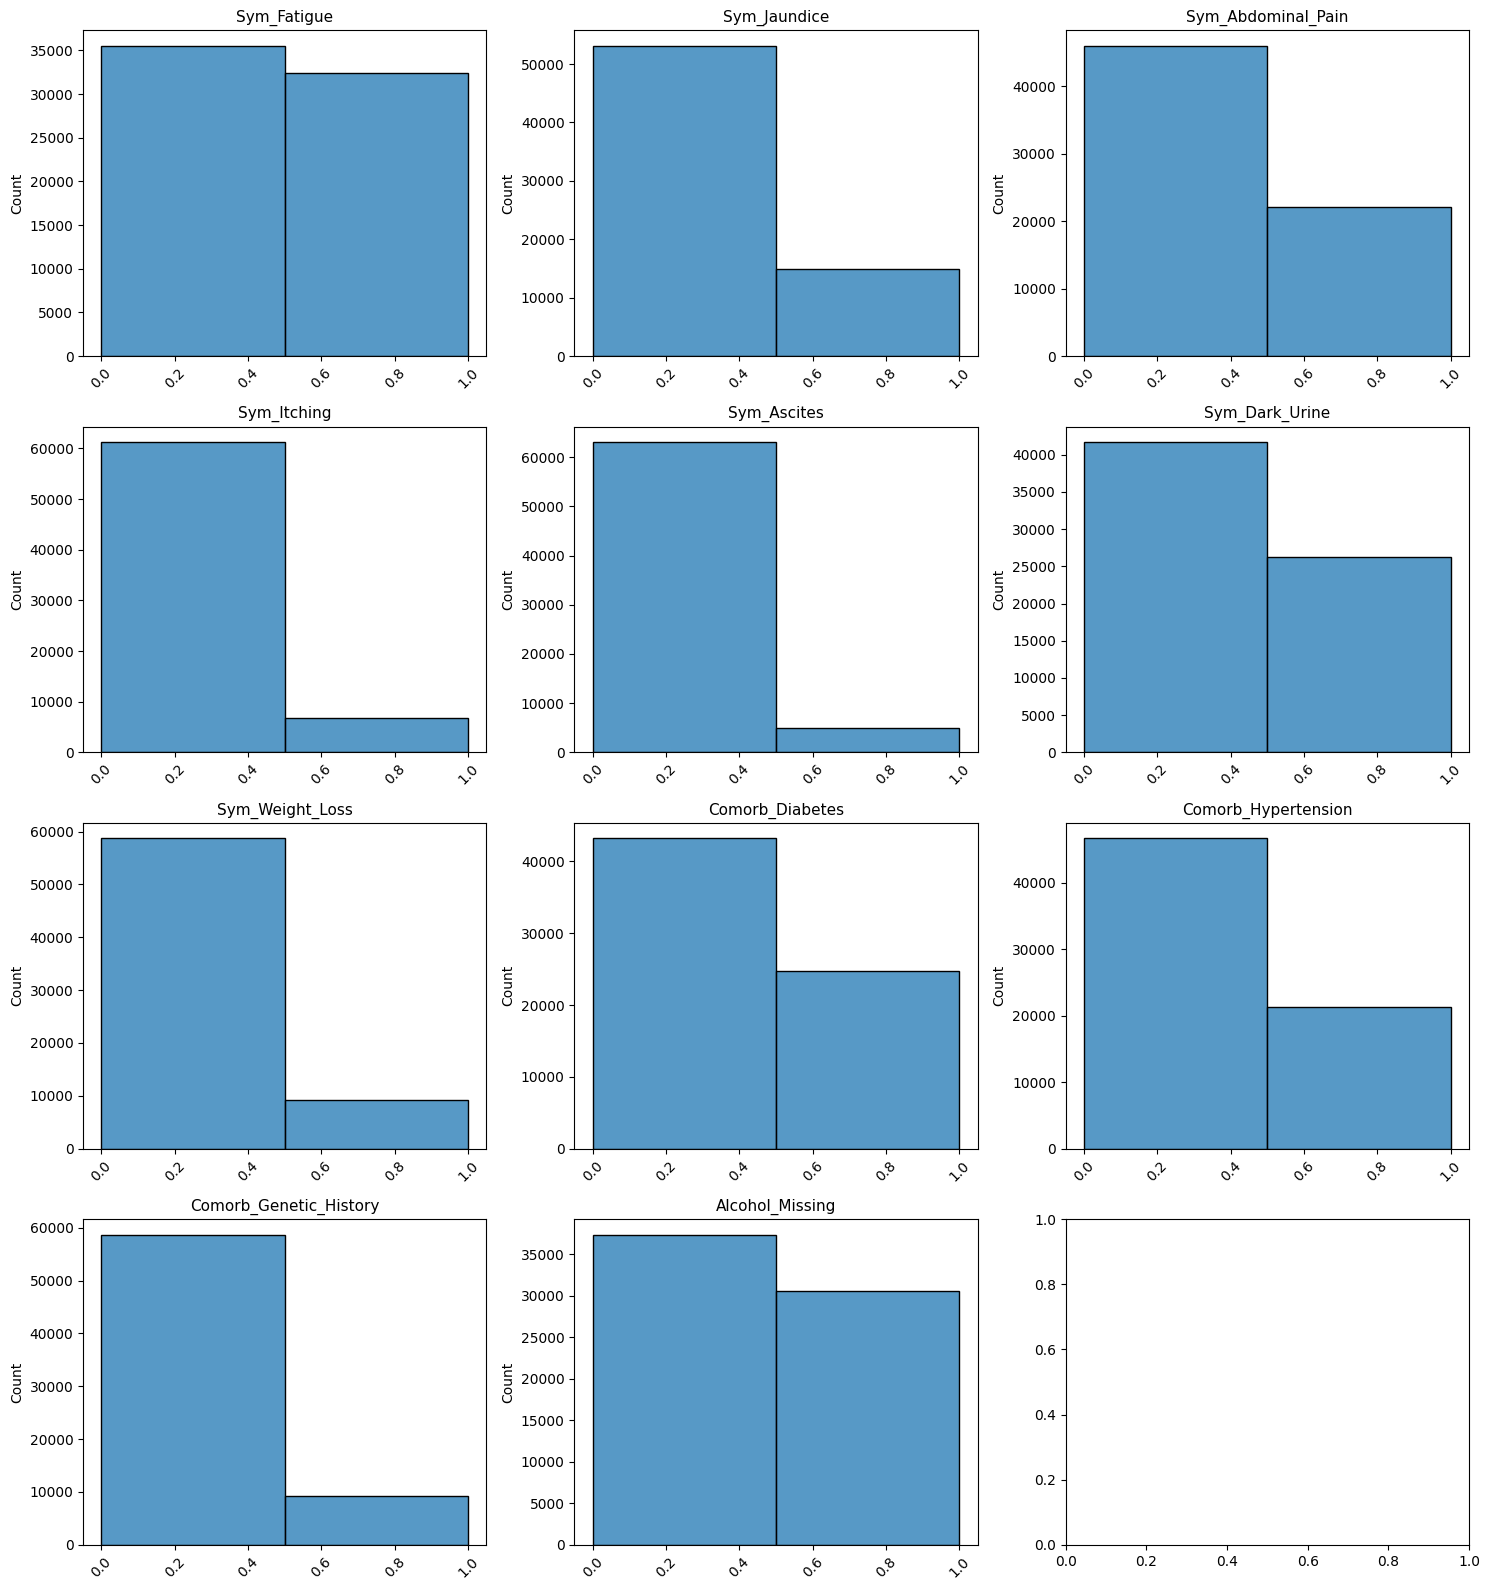

In [57]:
plot(df, binary_cols)

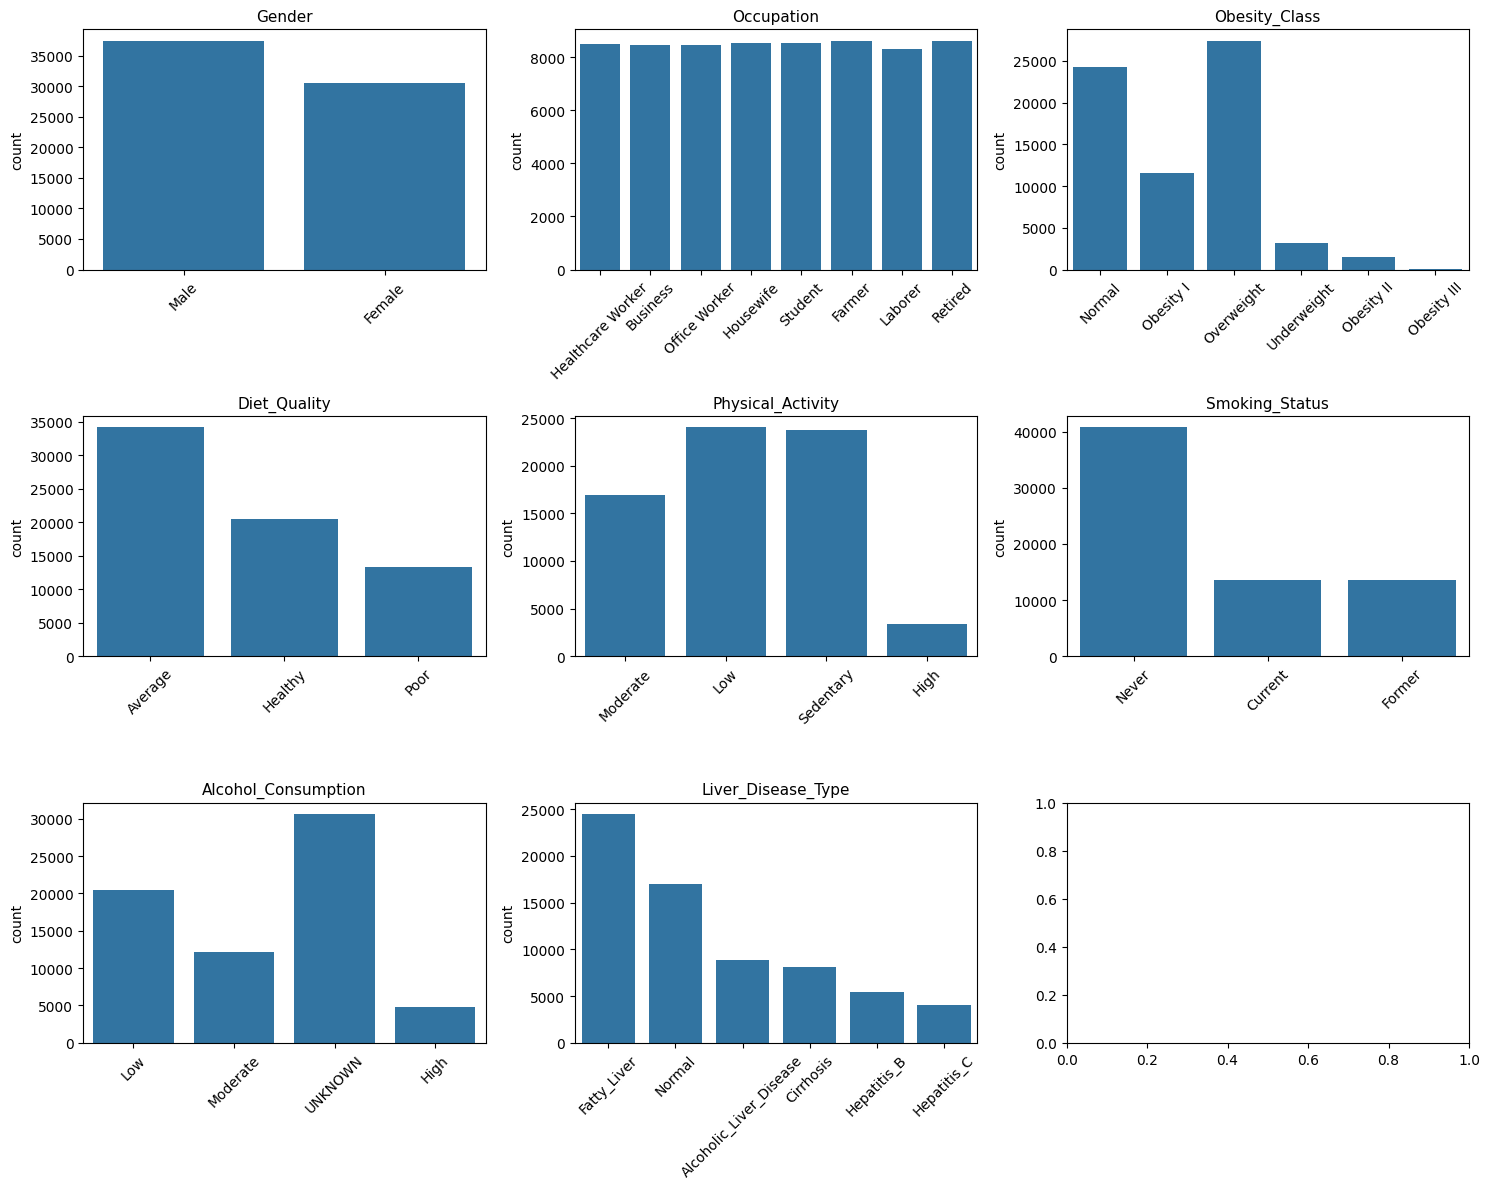

In [58]:
plot(df, list(cat_cols.columns), "categorical")

In [59]:
# Коэффициент Де Ритиса - важный параметр состояния печени

df["De_Ritis_ratio"] = df["AST"] / df["ALT"]

In [60]:
df.to_csv("../data/train_clear.csv", index=False)